# <center> 使用Transformer训练IWSLT2014英德数据集 </center>

## 1.加载库

In [1]:
#  导入库
import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.nn.utils.rnn import pad_sequence  # 作用: 序列填充 (Padding)
from datasets import load_dataset  # 所属库: Hugging Face Datasets (datasets), 作用: 加载和管理数据集。
from tokenizers import Tokenizer #从tokenizers 中导入Tokenizer类
from tokenizers.models import BPE  # BPE类定义结构与推理 管理推理参数
from tokenizers.trainers import BpeTrainer  # BpeTrainer定义训练过程, 管理训练参数
from tokenizers.pre_tokenizers import Whitespace  # 作用: 预分词器 (按空格切分)
# 使用示例
# BPE + BpeTrainer
#tokenizer_bpe = Tokenizer(BPE())
#trainer_bpe = BpeTrainer(vocab_size=10000)
#tokenizer_bpe.train(["data.txt"], trainer=trainer_bpe) 

import math
import time
import os
import warnings
warnings.filterwarnings('ignore')

## 2. Transformer 模型架构实现
详细阐述 Transformer 模型的模块化构建过程，从基础组件到完整的编码器 - 解码器架构。
### 2.1 核心基础组件
- **多头自注意力机制 (Multi-Head Attention)**
  - 功能：实现缩放点积注意力 (Scaled Dot-Product Attention)。
  - 特性：支持多头并行计算，使模型能同时关注不同子空间的信息。
  
- **位置编码 (Positional Encoding)**
  - 功能：为输入序列注入顺序信息，弥补注意力机制对位置不敏感的特性。
  - 实现：采用正弦/余弦固定公式或可学习参数。

- **前馈神经网络 (Position-wise Feed-Forward Networks)**
  - 结构：包含两个线性变换层，中间由 `ReLU` 激活函数连接。
  - 作用：对每个位置的表示进行独立的非线性变换。

- **辅助模块 (Normalization & Residuals)**
  - **层归一化 (Layer Normalization)**：稳定训练过程，加速收敛。
  - **残差连接 (Add & Residual)**：解决深层网络梯度消失问题，实现 `x + Sublayer(x)` 结构。


In [4]:
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # 维度为【1，max_len, 512]
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]  # 这里会自动广播
        return self.dropout(x)

### 2.2 编码器 - 解码器层级构建 (Layer Construction)
将基础组件组合成标准的网络层单元：

#### 编码器层 (Encoder Layer)
单个编码器层按顺序集成以下模块：
1. **多头自注意力**：捕捉序列内部依赖。
2. **残差连接 & 层归一化**。
3. **前馈神经网络**。
4. **残差连接 & 层归一化**。

In [5]:
class EncoderLayer(nn.Module):
    """编码器层"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # 多头自注意力 + 残差连接 + 层归一化
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # 前馈网络 + 残差连接 + 层归一化
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x

####  解码器层 (Decoder Layer)
单个解码器层结构更为复杂，包含三个子层：
1. **带掩码的多头自注意力 (Masked Multi-Head Attention)**。 关键点：引入掩码 (Mask) 防止当前位置关注到未来信息。
2. **残差连接 & 层归一化**。
3. **跨注意力机制 (Cross-Attention)**。关键点：Query 来自解码器，Key/Value 来自编码器输出，实现信息融合。
4. **残差连接 & 层归一化**。
5. **前馈神经网络**。
6. **残差连接 & 层归一化**。
> *注：每个子层后均跟随残差连接与层归一化。*

In [6]:
class DecoderLayer(nn.Module):
    """解码器层"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # 自注意力（掩码）
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # 交叉注意力
        attn_output, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        
        # 前馈网络
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        
        return x

### 2.3 完整模型组装 (Model Assembly)
最后，通过堆叠层级构建端到端的 Transformer 模型：

- **编码器栈 (Encoder Stack)**
  - 堆叠 $N$ 个相同的 **Encoder Layer**。
  - 输出：上下文相关的编码表示。

- **解码器栈 (Decoder Stack)**
  - 堆叠 $N$ 个相同的 **Decoder Layer**。
  - 输入：目标序列移位后的嵌入 + 编码器栈输出。

- **Transformer 主类 (The Transformer)**
  整合所有部分形成完整计算图：
  1. **输入嵌入层 (Input Embedding)**：将 Token 映射为向量。
  2. **位置编码叠加**：`Embedding + Positional Encoding`。
  3. **编码器栈**：处理源序列。
  4. **解码器栈**：生成目标序列。
  5. **最终线性投影层 (Linear Projection)**：将解码器输出映射到词汇表大小，接 `Softmax` 预测概率。

In [7]:
class Transformer(nn.Module):
    """完整的Transformer模型"""
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_heads=8, 
                 num_layers=6, d_ff=2048, max_len=100, dropout=0.1,  pad_idx=0):
        super().__init__()
        
        # 源语言（输入）和目标语言（输出）的词嵌入层
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        
        # 编码器层
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])  #创建了6个独立的层，此时它们还没有被‘连接’，只是放在了一个列表中
         
        # 解码器层
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 输出层
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model
        self._init_parameters()
    
    def _init_parameters(self):
        """Xavier初始化所有参数"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        
        # 嵌入层特殊初始化
        nn.init.normal_(self.encoder_embedding.weight, mean=0, std=self.d_model**-0.5)
        nn.init.normal_(self.decoder_embedding.weight, mean=0, std=self.d_model**-0.5)
        
        # 输出层特殊初始化
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0)

        
    def generate_mask(self, src, tgt):
        """生成掩码"""
        device = src.device
        # 源序列填充掩码
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2) #目的是形成与【batch_size,heads,seq_len,d_k]的掩码矩阵
        #注意力分数: (batch, heads, src_len, src_len)
        # mask需要: (batch, 1, 1, src_len) ← 匹配K的长度维度
        # 目标序列填充掩码
        tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, tgt_len, 1]
        # 因果掩码
        tgt_len = tgt.size(1)
        tgt_pad_mask = tgt_pad_mask.expand(-1, -1, tgt_len, -1) 
        causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)  # [1, 1, tgt_len, tgt_len]
       
        # 结合填充掩码和因果掩码
        tgt_mask = tgt_pad_mask & causal_mask   # 是&而不是|
        
        return src_mask, tgt_mask
    
    
    def forward(self, src, tgt):
        # 生成掩码
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        #print(f"Src Mask Mean: {src_mask.float().mean()}")
        #print(f"Tgt Mask Mean: {tgt_mask.float().mean()}")
        '''
        # --- 调试打印开始 ---
        if True: # 只在训练模式的前几个 batch 打印，避免刷屏，或者去掉这个 if 一直打印
            print("\n[DEBUG MASKS]")
            print(f"Src Shape: {src_mask.shape}, Tgt Shape: {tgt_mask.shape}")
            
            # 打印 Src 掩码向量 (取第一个样本)
            # src_mask: [B, 1, 1, S]
            s_vec = src_mask[0, 0, 0, :].int().tolist()
            print(f"Src Mask (first 20): {s_vec[:20]}")
            
            # 打印 Tgt 掩码矩阵 (取第一个样本)
            # tgt_mask: [B, 1, L, L]
            t_mat = tgt_mask[0, 0, :, :].int()
            print("Tgt Mask (first 3x3):")
            print(t_mat[:3, :3]) 
        # --- 调试打印结束 ---
        '''
        
        # 编码器
        src_embedded = self.dropout(self.positional_encoding(
            self.encoder_embedding(src) * math.sqrt(self.d_model)
        ))
        
        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)
        
        # 解码器
        tgt_embedded = self.dropout(self.positional_encoding(
            self.decoder_embedding(tgt) * math.sqrt(self.d_model)
        ))
        
        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask) # 对于encoder中K,V 是一样的
        
        # 输出
        output = self.fc_out(dec_output)
        
        return output

## 3.定义从本地加载数据集的函数
专门用于加载和处理 IWSLT 2014 英德翻译数据集

In [8]:
import re

def clean_iwslt_line(text):
    """
    清洗 IWSLT 数据中的 XML 标签和多余空白。
    IWSLT 原始数据有时包含 <seg>, <doc> 等标签，或者首尾空白。
    """
    # 去除首尾空白
    text = text.strip()
    # 简单的正则去除常见的 XML 标签 (如 <seg>, </seg>, <doc>, </doc> 等)
    # 如果数据非常干净没有标签，这步不会产生影响
    text = re.sub(r'<[^>]+>', '', text)
    return text.strip()

def load_local_iwslt(split="train", data_dir="/workspace/iwslt14", max_char_len=256):
    """
    加载本地 IWSLT 数据集的函数
    
    参数:
        split: 数据集划分 ('train', 'validation', 'test')
        data_dir: 数据目录
        max_char_len: 最大字符长度阈值。
                      **注意**: 这里用于过滤异常长的行，而不是截断。
                      真正的 Token 截断应在 Tokenizer 中进行。
                      对于翻译任务，建议设为 200-300 之间，避免丢失完整语义。
    """
    
    # 文件名映射
    file_map = {
        "train": ("train.tags.de-en.en", "train.tags.de-en.de"),
        "validation": ("IWSLT14.TED.dev2010.de-en.en", "IWSLT14.TED.dev2010.de-en.de"),
        "test": ("IWSLT14.TED.tst2012.de-en.en", "IWSLT14.TED.tst2012.de-en.de")
    }
    
    if split not in file_map:
        raise ValueError(f"不支持的 split: {split}")
    
    en_file, de_file = file_map[split]
    en_path = os.path.join(data_dir, en_file)
    de_path = os.path.join(data_dir, de_file)
    
    if not os.path.exists(en_path) or not os.path.exists(de_path):
        raise FileNotFoundError(f"未找到数据文件。请检查路径:\nEN: {en_path}\nDE: {de_path}")

    en_texts = []
    de_texts = []
    skipped_count = 0
    
    print(f"正在加载 {split} 数据集...")
    
    # 同时读取两个文件以确保行号对齐
    with open(en_path, 'r', encoding='utf-8') as f_en, \
         open(de_path, 'r', encoding='utf-8') as f_de:
        
        for line_en, line_de in zip(f_en, f_de):
            # 1. 清洗数据 (去除 XML 标签和空白)
            clean_en = clean_iwslt_line(line_en)
            clean_de = clean_iwslt_line(line_de)
            
            # 2. 基础有效性检查 (去除空行)
            if not clean_en or not clean_de:
                skipped_count += 1
                continue
            
            # 3. 长度过滤 (Filtering) 而不是截断 (Truncation)
            # 如果任一句子超过阈值，丢弃整对数据，防止语义不对齐
            if len(clean_en) > max_char_len or len(clean_de) > max_char_len:
                skipped_count += 1
                continue
            
            en_texts.append(clean_en)
            de_texts.append(clean_de)
    
    print(f"加载完成。原始行数对齐，过滤了 {skipped_count} 个样本 (原因: 空行 或 长度 > {max_char_len})")
    print(f"剩余有效样本数: {len(en_texts)}")

    # 转换为 Dataset 格式
    class LocalDataset:
        def __init__(self, en_list, de_list):
            self.data = []
            # 再次确认长度一致 (理论上 zip 后处理过应该一致，但做个防御性编程)
            assert len(en_list) == len(de_list), "英德数据长度不一致！"
            
            for en, de in zip(en_list, de_list):
                self.data.append({
                    'translation': {
                        'en': en,
                        'de': de
                    }
                })
        
        def __len__(self):
            return len(self.data)
        
        def __getitem__(self, idx):
            return self.data[idx]
            
        # 兼容 HuggingFace dataset 的一些常用方法 (可选)
        def column_names(self):
            return ['translation']
    
    return LocalDataset(en_texts, de_texts)


In [9]:
class IWLTDataset(Dataset):
    """IWSLT 2014 英德翻译数据集 - 使用本地数据"""
    def __init__(self, split="train", max_char_len=256, data_dir="/workspace/iwslt14"):
        super().__init__()
        # 使用本地加载函数
        self.dataset = load_local_iwslt(split=split, data_dir=data_dir, max_char_len=max_char_len)

        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        return item['translation']['en'], item['translation']['de']

## 4.定义分词器

In [10]:
def train_tokenizer(dataset, vocab_size=3000, save_path="workspace/tokenizer.json"):
    """训练BPE分词器"""
    # 收集所有文本
    texts = []
    for i in range(len(dataset)):
        en, de = dataset[i]
        texts.append(en)
        texts.append(de)
    
    # 初始化BPE分词器
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"], 
        min_frequency=2,        # 忽略出现次数太少的字符组合
        show_progress=True 
    )
    
    # 训练分词器
    tokenizer.train_from_iterator(texts, trainer)
    tokenizer.save(save_path)
    return tokenizer
'''
如果下次想直接用，可以加载训练好的分词器
tokenizer = Tokenizer.from_file("tokenizer.json")  # 直接加载

# 使用分词器
text = "Hello, how are you?"
encoded = tokenizer.encode(text)
print(encoded.ids)      # 输出token IDs
print(encoded.tokens)   # 输出tokens
'''

'\n如果下次想直接用，可以加载训练好的分词器\ntokenizer = Tokenizer.from_file("tokenizer.json")  # 直接加载\n\n# 使用分词器\ntext = "Hello, how are you?"\nencoded = tokenizer.encode(text)\nprint(encoded.ids)      # 输出token IDs\nprint(encoded.tokens)   # 输出tokens\n'

In [11]:
def collate_fn(batch, src_tokenizer, tgt_tokenizer, max_len=512):
    """批处理函数
    将 DataLoader 抓取的一个 Batch 的原始文本对 (src_text, tgt_text) 转换为模型训练所需的输入格式。
    执行了分词编码、特殊标记注入、长度控制以及序列填充四个关键步骤，确保同一个 Batch 内的所有样本具有相同的序列长度。
    """
    src_texts, tgt_texts = zip(*batch)
    #print(f"src_text: {src_texts[0:2]}")  # 直接索引
    #print(f"tgt_text: {tgt_texts[0:2]}")
    # 编码文本
    src_encoded = []
    tgt_encoded = []

    # 获取特殊token的ID
    pad_id = src_tokenizer.token_to_id("[PAD]")
    #print(f'pad_id:{pad_id}')
    sos_id = src_tokenizer.token_to_id("[SOS]")
    eos_id = src_tokenizer.token_to_id("[EOS]")
    
    for src_text, tgt_text in zip(src_texts, tgt_texts):
        # 添加特殊标记
        src_tokens = src_tokenizer.encode(src_text).ids
        tgt_tokens = tgt_tokenizer.encode(tgt_text).ids
        # 2. 手动添加特殊标记（在ID层面操作）
        # Encoder输入: 只有 [EOS] 在结尾
        src_tokens = src_tokens + [eos_id]  # 注意：不加 [SOS]
        
        # Decoder输入: [SOS] + 文本 + [EOS]
        tgt_tokens = [sos_id] + tgt_tokens + [eos_id]
        
        if len(src_tokens) > max_len:
            src_tokens =src_tokens[:max_len-1] + [eos_id]
        if len(tgt_tokens) > max_len:
            tgt_tokens = [sos_id] + tgt_tokens[1:max_len-1] + [eos_id]
        
        src_encoded.append(torch.tensor(src_tokens))
        tgt_encoded.append(torch.tensor(tgt_tokens))
    
    # 填充序列
    src_padded = pad_sequence(src_encoded, batch_first=True, padding_value=pad_id)
    tgt_padded = pad_sequence(tgt_encoded, batch_first=True, padding_value=pad_id)
    
    return src_padded, tgt_padded

## 5.`train_epoch` 函数

### 5.1. 功能简述
执行模型单轮（Epoch）训练。核心流程：**数据移位 → 前向传播 → 损失计算 → 梯度裁剪 → 参数/学习率更新**。

### 5.2. 关键参数
| 参数 | 说明 |
| :--- | :--- |
| model | Transformer 模型实例 |
| dataloader | 训练数据迭代器 (src, tgt) |
| optimizer / scheduler | 优化器与学习率调度器 |
| criterion| 损失函数 (CrossEntropy) |
| clip | 梯度裁剪阈值 (默认 1.0)，防爆炸 |

### 5.3. 核心逻辑

###  Teacher Forcing 数据移位
将目标序列错位，构造“输入”与“真实标签”：
```python
tgt_input  = tgt[:, :-1]  # 输入: [SOS, w1, w2...] (去掉 EOS)
tgt_target = tgt[:, 1:]   # 标签: [w1, w2, ...EOS] (去掉 SOS)

In [ ]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, epoch, clip=1.0):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        src, tgt = src.to(device), tgt.to(device)
        #print(f'src:{src[:1,:]}')
        optimizer.zero_grad()
        
        # 准备输入和目标
        tgt_input = tgt[:, :-1]  # 去掉EOS
        #print(f'tgt_input:{tgt_input[:1,:]}')
        tgt_target = tgt[:, 1:]  # 去掉SOS

        
        # 前向传播
        output = model(src, tgt_input)
        
        # 计算损失
        loss = criterion(output.reshape(-1, output.size(-1)), tgt_target.reshape(-1))
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        scheduler.step() 
        
        total_loss += loss.item()
        
        if batch_idx % 10 == 0:
            cur_loss = total_loss / (batch_idx + 1)
            elapsed = time.time() - start_time
            print(f'Epoch: {epoch:3d} | Batch: {batch_idx:5d}/{len(dataloader):5d} | '
                  f'Loss: {cur_loss:6.4f} | Time: {elapsed:5.1f}s')
    
    return total_loss / len(dataloader)

## 6.定义评估函数

In [13]:
def evaluate(model, dataloader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            
            tgt_input = tgt[:, :-1]
            tgt_target = tgt[:, 1:]
            
            output = model(src, tgt_input)
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_target.reshape(-1))
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

## 7.定义translate函数
执行单句翻译推理。采用**自回归（Autoregressive）**方式，逐个生成目标语言 token，直到遇到结束符 `[EOS]` 或达到最大长度限制。

In [14]:
def translate(model, sentence, src_tokenizer, tgt_tokenizer, device, max_len=256):
    model.eval()
    
    src_tokens = src_tokenizer.encode(sentence).ids
    eos_id = src_tokenizer.token_to_id("[EOS]")
    src_tokens = src_tokens + [eos_id]
    src_tensor = torch.tensor(src_tokens).unsqueeze(0).to(device)
    
    tgt_tokens = [tgt_tokenizer.token_to_id("[SOS]")]
    pad_id = tgt_tokenizer.token_to_id("[PAD]")
    
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)
        
        # 获取最后一个 token 的 logits
        next_token_logits = output[:, -1, :]
        
        # 可选：应用 Temperature 采样 (例如 temp=0.7) 增加多样性，防止过早陷入 PAD 或 EOS
        # 这里为了稳定性先保持 argmax，但确保不预测 PAD
        next_token_logits[:, pad_id] = -float('inf') 
        
        next_token = next_token_logits.argmax(-1).item()
        tgt_tokens.append(next_token)
        
        if next_token == tgt_tokenizer.token_to_id("[EOS]"):
            break
    
    # 解码时去掉 SOS 和 EOS
    # 注意：如果第一个生成的 token 就是 EOS，列表切片需小心
    if len(tgt_tokens) <= 2:
        return ""
        
    translation = tgt_tokenizer.decode(tgt_tokens[1:-1])
    return translation

## 8.定义plot_loss_curve函数
可视化训练过程中的损失变化趋势。同时绘制**训练损失**和**验证损失**曲线

In [15]:
import matplotlib
import matplotlib.pyplot as plt
def plot_loss_curve(train_losses, val_losses=None, save_path='loss_curve.png'):
    """
    绘制训练和验证损失曲线
    
    参数:
        train_losses: 训练损失列表，每个epoch一个值
        val_losses: 验证损失列表，每个epoch一个值（可选）
        save_path: 图片保存路径
    """
    plt.figure(figsize=(10, 6))
    
    epochs = range(1, len(train_losses) + 1)
    
    # 绘制训练损失
    plt.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=8, 
             label='Training Loss', alpha=0.8, markerfacecolor='white')
    
    if val_losses is not None:
        plt.plot(epochs[:len(val_losses)], val_losses, 'r-s', linewidth=2, 
                 markersize=8, label='Validation Loss', alpha=0.8, 
                 markerfacecolor='white')
    
    # 添加最后一点的数值标签
    if train_losses:
        plt.annotate(f'{train_losses[-1]:.4f}', 
                    xy=(len(train_losses), train_losses[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, color='blue')
    
    if val_losses and len(val_losses) == len(train_losses):
        plt.annotate(f'{val_losses[-1]:.4f}', 
                    xy=(len(val_losses), val_losses[-1]),
                    xytext=(5, -15), textcoords='offset points',
                    fontsize=10, color='red')
    
    # 设置图表属性
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    
    title = 'Training Loss' + (' and Validation Loss' if val_losses else '')
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # 设置y轴范围，留出一些空间
    all_losses = train_losses + (val_losses if val_losses else [])
    y_min, y_max = min(all_losses), max(all_losses)
    plt.ylim([y_min * 0.9, y_max * 1.1])
    
    # 添加次要网格
    plt.grid(True, which='minor', alpha=0.2, linestyle=':')
    
    # 可以选择使用对数刻度（如果损失变化范围很大）
    if max(all_losses) / min(all_losses) > 100:  # 如果最大最小相差100倍以上
        plt.yscale('log')
        plt.ylabel('Loss (log scale)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # 保存图片
    #plt.savefig(save_path, dpi=150, bbox_inches='tight')
    #print(f"损失曲线已保存到: {save_path}")
    
    plt.show()

##  9.定义main函数：训练流程总控

### 核心配置 (Hyperparameters)
| 参数 | 值 | 说明 |
| :--- | :--- | :--- |
| BATCH_SIZE | 32 | 批次大小 |
| NUM_EPOCHS | 11 | 训练轮数 |
| D_MODEL | 256 | 模型嵌入维度 |
| NUM_HEADS / NUM_LAYERS| 8 /3 | 多头注意力数 / 编码器 - 解码器层数 |
| VOCAB_SIZE | 12000 | 词汇表大小 |
| Dropout | 0.3 | 正则化比率 |

### 代码结构概览
```python
def main():
    # 1. 配置超参数
    # 2. 设置设备 (GPU/CPU)
    # 3. 加载数据 & 训练分词器
    # 4. 创建 DataLoader
    # 5. 初始化模型、优化器、Scheduler、Loss
    # 6. 训练循环 (for epoch in epochs):
    #    - train_epoch()
    #    - evaluate()
    #    - 保存最佳模型 (if val_loss < best)
    #    - 定期示例翻译 (if epoch % 5 == 0)
    # 7. 绘制损失曲线

In [19]:

def main():
    """主训练函数"""
    # 超参数
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    D_MODEL = 256
    NUM_HEADS = 8
    NUM_LAYERS = 3
    D_FF = 512
    MAX_LEN = 128
    LEARNING_RATE = 1.0
    VOCAB_SIZE = 12000
    
    # 设置设备
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")
    if torch.cuda.is_available():
        print(f"GPU型号: {torch.cuda.get_device_name(0)}")
    
    # 加载数据集
    print("加载数据集...")
    train_dataset = IWLTDataset("train", max_char_len=MAX_LEN)
    val_dataset = IWLTDataset("validation", max_char_len=MAX_LEN)
    
    # 训练分词器
    print("训练分词器...")
    src_tokenizer = train_tokenizer(train_dataset, VOCAB_SIZE, "workspace/src_tokenizer.json")
    # 加载已训练的分词器
    #src_tokenizer = Tokenizer.from_file("workspace/src_tokenizer.json")  # 第一次使用需要用上一行个行代码训练，后面直接加载就可以了
    tgt_tokenizer = train_tokenizer(train_dataset, VOCAB_SIZE, "workspace/tgt_tokenizer.json")
    #tgt_tokenizer = Tokenizer.from_file("workspace/tgt_tokenizer.json") 
    
    # 创建数据加载器
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda batch: collate_fn(batch, src_tokenizer, tgt_tokenizer, MAX_LEN)
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=lambda batch: collate_fn(batch, src_tokenizer, tgt_tokenizer, MAX_LEN)
    )
    
    # 创建模型
    print("创建模型...")
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,  
        tgt_vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        d_ff=D_FF,
        max_len=MAX_LEN,
        dropout=0.4
    ).to(device)
    
    # 计算参数量
    num_params = sum(p.numel() for p in model.parameters())
    print(f"模型参数量: {num_params:,}")
    print(f"可训练参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # 定义优化器和损失函数
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)
    
    # 学习率调度器
    def lr_lambda(step, d_model=256, warmup_steps=4000):
        if step == 0:
            return 1e-7
        scale_factor = d_model ** -0.5

        return scale_factor*min(step ** -0.5, step * warmup_steps ** -1.5)
    
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # 忽略padding的损失
    criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
    #criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

    train_losses = []
    val_losses = []
    
    # 训练循环
    print("开始训练...")
    best_val_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        start_time = time.time()
        
        # 训练
        train_loss = train_epoch(model, train_loader, optimizer,scheduler, criterion, device, epoch)
        train_losses.append(train_loss)
        
        # 验证
        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)


        #scheduler.step() # 内部已经更新过
        
        # 保存最佳模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'workspace/best_transformer.pth')
            print(f"✓ 保存最佳模型，验证损失: {val_loss:.4f}")
        
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch} 完成 | "
              f"训练损失: {train_loss:.4f} | "
              f"验证损失: {val_loss:.4f} | "
              f"时间: {epoch_time:.1f}s")
        
        # 示例翻译
        if epoch % 5 == 0:
            test_sentences = [
                "Hello, how are you?",
                "I love machine learning.",
                "The weather is nice today."
            ]
            
            print("\n示例翻译:")
            for sentence in test_sentences:
                translation = translate(model, sentence, src_tokenizer, tgt_tokenizer, device)
                print(f"英文: {sentence}")
                print(f"德文: {translation}")
                print("-" * 50)
            print()
    # 训练结束后绘制损失曲线
    plot_loss_curve(train_losses, val_losses)
   

使用设备: cuda
GPU型号: Tesla T4
加载数据集...
正在加载 train 数据集...
加载完成。原始行数对齐，过滤了 48984 个样本 (原因: 空行 或 长度 > 128)
剩余有效样本数: 129542
正在加载 validation 数据集...
加载完成。原始行数对齐，过滤了 330 个样本 (原因: 空行 或 长度 > 128)
剩余有效样本数: 557
训练分词器...






创建模型...
模型参数量: 13,181,664
可训练参数量: 13,181,664
开始训练...
Epoch:   0 | Batch:     0/ 4049 | Loss: 9.4005 | Time:   0.1s
Epoch:   0 | Batch:    10/ 4049 | Loss: 9.4035 | Time:   0.5s
Epoch:   0 | Batch:    20/ 4049 | Loss: 9.3974 | Time:   0.9s
Epoch:   0 | Batch:    30/ 4049 | Loss: 9.3926 | Time:   1.3s
Epoch:   0 | Batch:    40/ 4049 | Loss: 9.3848 | Time:   1.6s
Epoch:   0 | Batch:    50/ 4049 | Loss: 9.3767 | Time:   2.0s
Epoch:   0 | Batch:    60/ 4049 | Loss: 9.3663 | Time:   2.4s
Epoch:   0 | Batch:    70/ 4049 | Loss: 9.3537 | Time:   2.7s
Epoch:   0 | Batch:    80/ 4049 | Loss: 9.3393 | Time:   3.1s
Epoch:   0 | Batch:    90/ 4049 | Loss: 9.3231 | Time:   3.5s
Epoch:   0 | Batch:   100/ 4049 | Loss: 9.3055 | Time:   3.9s
Epoch:   0 | Batch:   110/ 4049 | Loss: 9.2862 | Time:

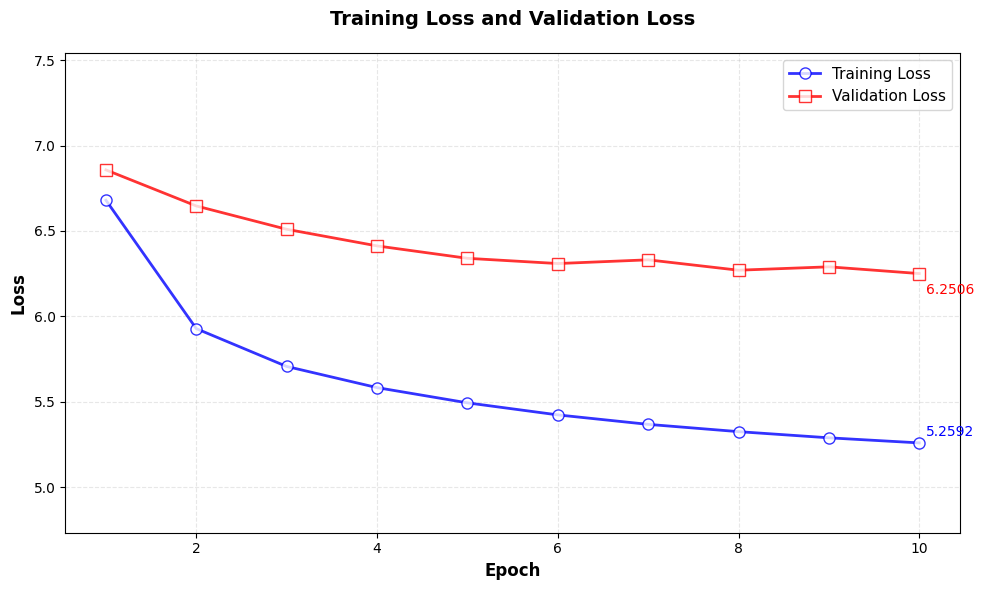

In [21]:
if __name__ == "__main__":
    main()